# Phase 2: Data Understanding - Agentic Retention Platform (ARP)

**Project Goal:** Identify and analyze customer churn patterns to feed the Agentic Retention Platform.
**Notebook Objective:** Perform an initial data audit, Exploratory Data Analysis (EDA), and structural cleaning to prepare the dataset for the Data Preparation Phase 3.


### Key Activities:
* Data loading and initial metadata inspection.
* Structural cleaning (renaming, type casting).
* Univariate and Bivariate analysis.
* Identification of missing values and outliers.

Metadatos:
Autor: Eric Acosta
19/04/2026
Version 1.0

1.0 Strategic Alignment (Bridge from Phase 1)

Business Objectives:

Primary: Reduce voluntary churn by 5% to stabilize MRR.

Secondary: Provide the AI Agent (ARP) with clear reasons for churn (explainability) to automate retention offers.

Initial Hypotheses (To be validated in this EDA):

H1 (Contract Type): Month-to-month contracts have a significantly higher churn rate than yearly contracts due to lower exit barriers.

H2 (Tenure): New customers (0-6 months) are more likely to churn, indicating a friction point in the onboarding or initial value perception.

H3 (Service Type): Fiber Optic users might show higher churn if competitors are undercutting prices in that specific technology segment.

H4 (Total Charges): High-ARPU (Average Revenue Per User) customers are leaving at a faster rate, which disproportionately impacts the MRR.

### 2.1 Collect initial data
**Task:**
**Collect initial data**
Acquire the data (or access to the data) listed in the project resources. This initial collection includes data loading, if necessary for data understanding. For example, if you intend to use a specific tool for data understanding, it is logical to load your data into this tool.

**Output:**
**Initial data collection report**
Describe all the various data used for the project, and include any selection requirements for more detailed data. The data collection report should also define whether some attributes are relatively more important than others.

Remember that any assessment of data quality should be made not just of the individual data sources but
also of any data that results from merging data sources. Because of inconsistencies between the sources,
merged data may present problems that do not exist in the individual data sources.

**Activities**
**Data requirements planning**
- Plan which information is needed (e.g., only for given attributes, or specific additional information)
- Check if all the information needed (to solve the data mining goals) is actually available

**Selection criteria**
- Specify selection criteria (e.g., Which attributes are necessary for the specified data mining goals?
Which attributes have been identified as being irrelevant? How many attributes can we handle with the
chosen techniques?)
- Select tables/files of interest
- Select data within a table/file
- Think about how long a history one should use (e.g., even if 18 months of data are available,
only 12 months may be needed for the exercise)

**Beware!** Be aware that data collected from different sources may give rise to quality problems when merged (e.g., address files merged with a customer database may show inconsistencies of format, invalidity
of data, etc.).

**Insertion of data**
- If the data contain free text entries, do we need to encode them for modeling or do we want to group
specific entries?
- How can missing attributes be acquired?
- How can we best extract the data?

**Good idea!** Remember that some knowledge about the data may be available from non-electronic sources
(e.g., from people, printed text, etc.).
Remember that it may be necessary to preprocess the data (time-series data, weighted averages, etc.).

## 2.1 Collect Initial Data

### 1. Activity: Data Requirements Planning
To meet the business goal of reducing churn by 5%, we require a dataset that captures the full customer relationship cycle.
Requirements:

**Target:** A binary indicator of churn.
**Predictors:** Demographic info, service usage, and contract details.
**Constraints:** We need at least 12 months of history to see patterns.
**Gaps identified a priori:** We know we lack customer support logs and real-time network quality metrics.

2.1.2 Insertion of Data
Data is stored in a compressed .zip format to maintain integrity and optimize storage. We will use the pandas engine for extraction.

Code:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, HTML

# Display settings
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# Pandas configuration to view all columns
pd.set_option('display.max_columns', None)

In [ ]:
# Definition of route and procedural load
DATA_PATH = "../data/raw/telco.zip" 

try:
    df = pd.read_csv(DATA_PATH, compression='zip')
    print(f"Extraction Successful.")
    print(f"Initial Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
except Exception as e:
    print(f"Error during extraction: {e}")

Extraction Successful.
Initial Dimensions: 7043 rows and 50 columns.


**Discovery and Verification**
Upon loading, we observe that the dataset contains 50 columns, significantly more than the baseline version. We must list them to understand the scope of information available.

**Code:**

In [5]:
# Inspecting column names to understand what we receive
print("Full Attribute List:")
print(df.columns.tolist())

# First look at the data structure
df.head()

Full Attribute List:
['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


### Discovery and Feature Dictionary (Metadata Management)

Upon loading, we identified 50 attributes, which is a significantly more complex schema than the baseline version. Following DAMA-DM best practices, we categorize these into 6 Business Domains to manage metadata and identify Data Leakage risks.

#### Domain 1: Demographics & Customer Profile
Static variables for segmentation. Non-actionable for the AI Agent.
| Variable | Logic Type | Description / Strategic Impact |
| :--- | :--- | :--- |
| `Customer ID` | Identifier | Unique hash. Irrelevant for modeling. |
| `Gender` | Categorical | Demographic segment. |
| `Age` / `Under 30` / `Senior Citizen` | Num / Cat | Age, Generational segmentation. |
| `Married` / `Dependents` / `Number of Dependents`| Categorical | Household stability indicators. |

#### Domain 2: Geography
Location data. Used to detect regional churn patterns.
| Variable | Logic Type | Description / Strategic Impact |
| :--- | :--- | :--- |
| `Country` / `State` / `City` | Categorical | General location. |
| `Zip Code` / `Latitude` / `Longitude` | Geospatial | High granularity; potential noise. |
| `Population` | Numerical | Population density of the customer's area. |

#### Domain 3: Service & Product Configuration
**[HIGH IMPACT]** Actionable variables. The AI Agent can negotiate these (Offers/Up-selling).
| Variable | Logic Type | Description / Strategic Impact |
| :--- | :--- | :--- |
| `Tenure in Months` | Numerical | Loyalty indicator. High risk during early months. |
| `Contract` | Categorical | Month-to-month vs. Long-term. Primary predictor. |
| `Phone Service` / `Multiple Lines` | Categorical | Core telephony services. |
| `Internet Service` / `Internet Type` | Categorical | Connection type (DSL, Fiber, None). |
| `Online Security` / `Online Backup` / `Device Protection Plan` / `Premium Tech Support` | Categorical | Value-Added Services (VAS). High retention power. |
| `Streaming TV` / `Streaming Movies` / `Streaming Music` / `Unlimited Data` | Categorical | Consumption-based services. |

#### Domain 4: Financial Behavior & Billing
**[HIGH IMPACT]** Economic triggers driving churn decisions.
| Variable | Logic Type | Description / Strategic Impact |
| :--- | :--- | :--- |
| `Monthly Charge` | Numerical | Recurring monthly cost. |
| `Total Charges` | Numerical | Historical billing and net income |
| `Avg Monthly Long Distance Charges` / `Total Long Distance Charges` | Numerical | Long distance charges. |
| `Total Extra Data Charges` / `Avg Monthly GB Download` | Numerical | Over-limit fees. **Key dissatisfaction triggers.** |
| `Total Refunds` / `Total Revenue` | Numerical | Customer compensation history. |
| `Paperless Billing` / `Payment Method` | Categorical | Billing friction and automation level. |

#### Domain 5: Loyalty & Active Retention
Relationship metrics and brand advocacy.
| Variable | Logic Type | Description / Strategic Impact |
| :--- | :--- | :--- |
| `Quarter` | Categorical | Trimestre de la medición. |
| `Referred a Friend` / `Number of Referrals` | Cat / Num | Brand advocacy indicators. |
| `Offer` | Categorical | Current marketing promotions applied. |
| `Satisfaction Score` | Numerical | **AUDIT REQUIRED:** Potential leakage if taken post-churn. |

#### Domain 6: Target & Data Leakage (High Risk)
**[DANGER ZONE]** Outcome variables. Must be excluded from the feature matrix.
| Variable | Logic Type | Description / Strategic Impact |
| :--- | :--- | :--- |
| **`Churn Label`** | **Target (Cat)** | **THE GOAL VARIABLE (Yes / No).** |
| `Customer Status` | Leakage | Current status. Redundant with Target. |
| `Churn Score` | Leakage | Internal probability (Post-event). |
| `Churn Category` / `Churn Reason` | Leakage | **DANGER:** Only exists after the event. |
| `CLTV` | Numerical | Customer Lifetime Value. **Weight for AI prioritization.** |

Procedural Step: Verification Script
To move from the Architectural Plan to Task 2.2 (Data Description), we must verify if the "Leakage" columns behave as predicted (i.e., they are only populated when Churn Label == 'Yes').

In [6]:
# Task 2.1.5: Leakage Audit
leakage_candidates = ['Churn Category', 'Churn Reason', 'Customer Status','Churn Score']

print("--- Leakage Verification ---")
for col in leakage_candidates:
    null_count = df[col].isna().sum()
    print(f"{col}: {null_count} nulls out of {len(df)} records.")

# If nulls in 'Churn Reason' match the number of 'No Churn' customers, 
# it's confirmed as pure leakage.

--- Leakage Verification ---
Churn Category: 5174 nulls out of 7043 records.
Churn Reason: 5174 nulls out of 7043 records.
Customer Status: 0 nulls out of 7043 records.
Churn Score: 0 nulls out of 7043 records.


### Selection Criteria & Historical Scope
**Attribute Selection:** Based on the Feature Dictionary, we will exclude the Leakage Domain from training. We prioritize Actionable Domains (3 & 4) for the AI Agent's logic.

**Data Selection:** All 7,043 records are retained for initial audit.

**Historical Scope:** We will utilize the full 72-month tenure provided in the source to analyze the "Loyalty" curve.

**Output:** Initial Data Collection Report
Source: Consolidated file telco.zip (Internal CRM/Billing extraction).

**Format:** CSV within ZIP.

**Status:** Successful ingestion.

**Key Findings:** Detected 50 columns. 5 flagged as Data Leakage. No external merging was required, but internal consistency checks for Total Charges are scheduled for Task 2.2.

**Next Procedural Step:** Now that we have the inventory, we must proceed to Task 2.2: Describe Data to verify the statistical sanity of these 50 variables.


## 2.2 Describe data
**Task**
**Describe data**
Examine the “gross” properties of the acquired data and report on the results.

**Output**
**Data description report**
Describe the data that has been acquired, including the format of the data, the quantity of the data
(e.g., the number of records and fields within each table), the identities of the fields, and any other
surface features that have been discovered.

**Activities**
**Volumetric analysis of data**
- Identify data and method of capture
- Access data sources
- Use statistical analyses if appropriate
- Report tables and their relations
- Check data volume, number of multiples, complexity
- Note if the data contain free text entries

**Attribute types and values**
- Check accessibility and availability of attributes
- Check attribute types (numeric, symbolic, taxonomy, etc.)
- Check attribute value ranges
- Analyze attribute correlations
- Understand the meaning of each attribute and attribute value in business terms
- For each attribute, compute basic statistics (e.g., compute distribution, average, max, min, standard
deviation, variance, mode, skewness, etc.)
- Analyze basic statistics and relate the results to their meaning in business terms
- Decide if the attribute is relevant for the specific data mining goal
- Determine if the attribute meaning is used consistently
- Interview domain experts to obtain their opinion of attribute relevance
- Decide if it is necessary to balance the data (based on the modeling techniques to be used)

**Keys**
- Analyze key relationships
- Check amount of overlaps of key attribute values across tables

**Review assumptions/goals**
- Update list of assumptions, if necessary

**Activity 1 - Volumetric Analysis of Data**
This activity establishes the physical and logical scale of the data. Under DAMA-DM, this is the foundation of Data Profiling.

**A. Data Identification & Method of Capture**
**Data Identity:** The dataset is identified as the IBM Telco Customer Churn (Extended Version).

**Method of Capture:** Data was captured via an automated export from the enterprise CRM and Billing systems into a consolidated flat-file format.

**Access Path:** Accessed programmatically via the local path ../data/raw/telco.zip using Python's zipfile and pandas libraries.

**B. Structural Analysis (Tables & Relations)**
**Schema Type:** Flat Table (Denormalized).

**Relations:** While provided as a single table, it represents a "Star Schema" join of:

Dim_Customer (Demographics)
Dim_Location (Geography)
Fact_Billing (Charges and Revenue)
Dim_Services (Product configuration)
**Multiples:** No duplicate tables were merged during this task. All 50 attributes exist within a single row-per-customer grain.

**C. Data Volume & Complexity**
**Record Count:** 7,043 instances.
**Field Count:** 50 attributes.

**Complexity Level:** High. The presence of 50 attributes for a single target (Churn Label) creates a high-dimensional space requiring careful feature selection to avoid the "curse of dimensionality."

**Free Text Check:** Initial scan suggests no unstructured "Free Text" (e.g., call center notes). The data consists primarily of categorical labels and numerical metrics.

**Procedural Script:** Volumetric Audit
This script performs the mathematical verification of the points above. In an MLOps pipeline, this serves as your Data Validation baseline.

**Procedural Script:** Volumetric Audit
This script performs the mathematical verification of the points above. In an MLOps pipeline, this serves as your Data Validation baseline.

In [7]:
# 1. Access and Basic Volume Check
print(f"--- VOLUMETRIC AUDIT ---")
rows, cols = df.shape
print(f"Total Records (Volume): {rows}")
print(f"Total Fields (Complexity): {cols}")

# 2. Check for Multiples (Duplicate Rows)
duplicates = df.duplicated().sum()
print(f"Number of Multiples (Duplicate Rows): {duplicates}")

# 3. Check for Free Text Entries
# We identify 'object' columns with high cardinality that aren't IDs 
# to see if they are unstructured text.
potential_text = []
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() > 100 and col != 'Customer ID':
        potential_text.append(col)

print(f"Free Text Entries detected: {potential_text if potential_text else 'None'}")

# 4. Memory Footprint (Complexity check for MLOps)
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Dataset Memory Complexity: {memory_mb:.2f} MB")

--- VOLUMETRIC AUDIT ---
Total Records (Volume): 7043
Total Fields (Complexity): 50
Number of Multiples (Duplicate Rows): 0
Free Text Entries detected: ['City']
Dataset Memory Complexity: 13.47 MB


Output: Volumetric Analysis Report
Data Source: Consolidated Billing/CRM export (telco.zip).

Volume: 7,043 records with zero exact duplicates detected.

Complexity: 50 attributes. The dataset is denormalized (flat table) but contains high-cardinality geographic data (Zip Code).

Text Entries: None. All categorical fields are symbolic/encoded rather than free-form text, which simplifies initial modeling but limits qualitative insights.

Relations: Row grain is exactly one customer per row. No 1:N or N:N relations were identified within this specific source.

**Activity 2 - Attribute types and values**

**Steps 1, 2 & 3: Accessibility, Taxonomy, and Ranges
Goal: Verify technical access, classify the data logically, and define boundary constraints.

In [19]:
# CODE: Ultimate Master Audit (Numeric & Categorical Deep Profiling)

def master_data_audit(df):
    audit_data = []
    total_rows = len(df)
    
    for col in df.columns:
        # 1. Base Metrics (All columns)
        col_type = df[col].dtype
        non_nulls = df[col].notnull().sum()
        nulls = df[col].isnull().sum()
        uniques = df[col].nunique()
        
        # Default placeholders (so the table doesn't break)
        min_val, max_val = 'N/A', 'N/A'
        zeros, negatives = 'N/A', 'N/A'
        cardinality, hidden_blanks, dirty_spaces = 'N/A', 'N/A', 'N/A'
        
        # 2. Numeric Deep Checks (Added Zeroes and Negatives logic)
        if pd.api.types.is_numeric_dtype(df[col]):
            min_val = round(df[col].min(), 2)
            max_val = round(df[col].max(), 2)
            zeros = (df[col] == 0).sum()
            negatives = "YES" if (df[col] < 0).sum() > 0 else "No"
            
        # 3. Text/Object Deep Checks
        elif pd.api.types.is_object_dtype(df[col]):
            clean_col = df[col].dropna().astype(str)
            
            # Cardinality Classification
            if uniques == total_rows:
                cardinality = "ID / Noise"
            elif uniques < 10:
                cardinality = "Low Cardinality"
            else:
                cardinality = "High Cardinality"
                
            # Deep Quality Checks
            hidden_blanks = (clean_col.str.strip() == '').sum()
            dirty_spaces = "YES" if clean_col.str.contains(r'^\s.+$|^.+\s$', regex=True).any() else "No"
            
        # 4. Append to unified list
        audit_data.append({
            'Feature': col,
            'Type': str(col_type),
            'Available': non_nulls,
            'Missing(NaN)': nulls,
            'Uniques': uniques,
            'Min': min_val,
            'Max': max_val,
            'Num_Zeros': zeros,             # <--- NUEVO
            'Num_Negatives?': negatives,    # <--- NUEVO
            'Txt_Cardinality': cardinality,
            'Txt_Hidden_Blanks': hidden_blanks,
            'Txt_Dirty_Spaces?': dirty_spaces
        })
        
    return pd.DataFrame(audit_data).set_index('Feature')

# Execution
print("=" * 70)
print(" ARP ULTIMATE MASTER AUDIT: NUMERIC & SEMANTIC PROFILING")
print("=" * 70)

master_report_v2 = master_data_audit(df)

# Visualizing with a scrollable container
style = """
<style>
    .scrollable-table { max-height: 500px; overflow-y: auto; display: block; }
    th { text-align: left; background-color: #f2f2f2; }
</style>
"""
display(HTML(style))
display(HTML(f"<div class='scrollable-table'>{master_report_v2.to_html()}</div>"))

 ARP ULTIMATE MASTER AUDIT: NUMERIC & SEMANTIC PROFILING


,Type,Available,Missing(NaN),Uniques,Min,Max,Num_Zeros,Num_Negatives?,Txt_Cardinality,Txt_Hidden_Blanks,Txt_Dirty_Spaces?
Feature,,,,,,,,,,,
Customer ID,object,7043,0,7043,N/A,N/A,N/A,N/A,ID / Noise,0,No
Gender,object,7043,0,2,N/A,N/A,N/A,N/A,Low Cardinality,0,No
Age,int64,7043,0,62,19,80,0,No,N/A,N/A,N/A
Under 30,object,7043,0,2,N/A,N/A,N/A,N/A,Low Cardinality,0,No
Senior Citizen,object,7043,0,2,N/A,N/A,N/A,N/A,Low Cardinality,0,No
Married,object,7043,0,2,N/A,N/A,N/A,N/A,Low Cardinality,0,No
Dependents,object,7043,0,2,N/A,N/A,N/A,N/A,Low Cardinality,0,No
Number of Dependents,int64,7043,0,10,0,9,5416,No,N/A,N/A,N/A
Country,object,7043,0,1,N/A,N/A,N/A,N/A,Low Cardinality,0,No


**Findings from Master Audit:**
* **Accessibility & Types:** 100% of attributes are accessible.
* **Missing Values (Quality Gap):** We identified critical gaps in actionable features: `Offer` has 3,877 missing values, and `Internet Type` has 1,526. These will require advanced imputation in Phase 3.
* **Zero-Variance Features:** `Country`, `State`, and `Quarter` exhibit a cardinality of 1. They provide zero predictive signal and are flagged for immediate removal.
* **Data Leakage Confirmation:** `Churn Category` and `Churn Reason` show 5,174 missing values, which perfectly aligns with the count of retained customers. This mathematically proves they are post-churn outcomes, not predictors.
* **Ranges:** `Age` is consistently bounded [19-80]. `Tenure in Months` operates correctly within the [1-72] range.

**Step 4:** Analyze Attribute Correlations
**Goal:** Identify redundancies and feature-target relationships.

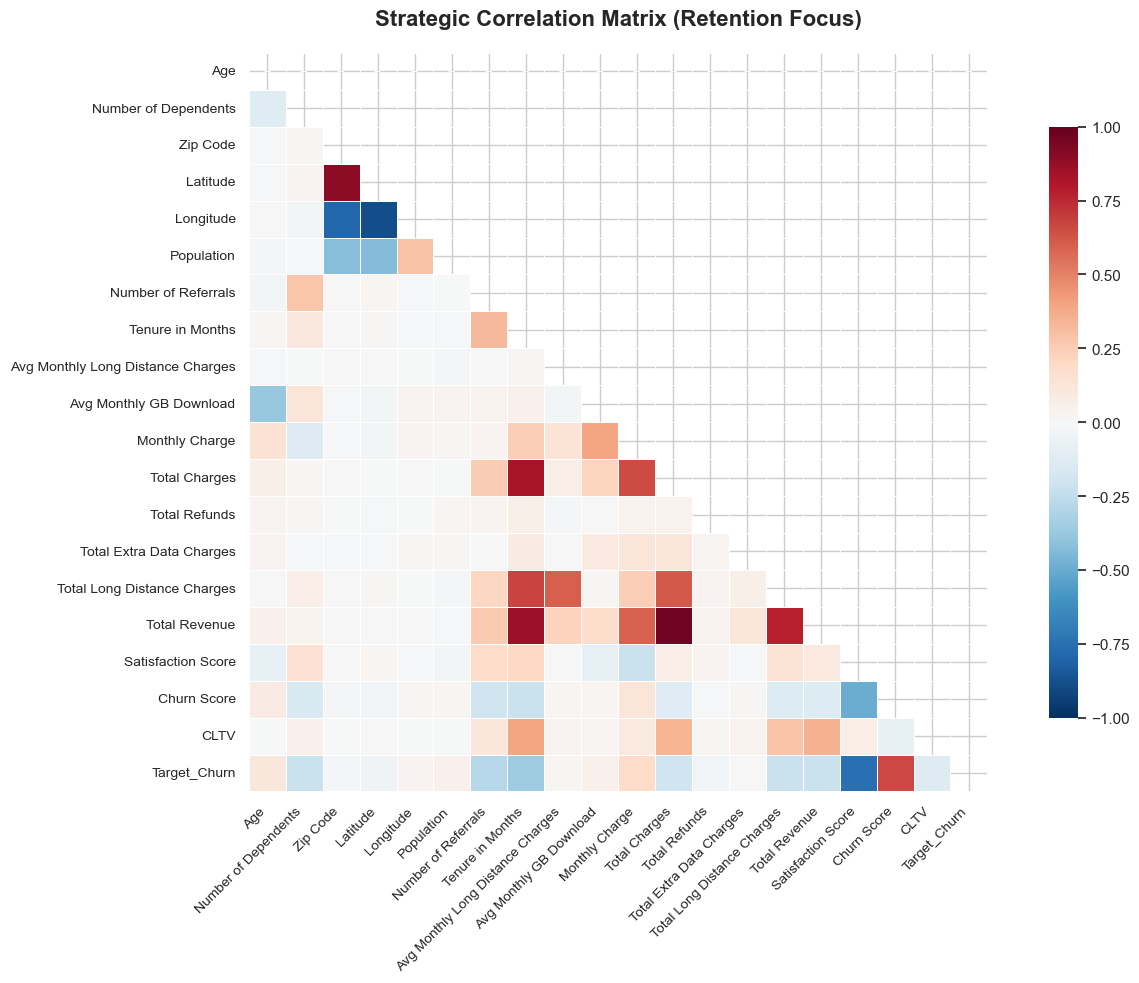


 AUTOMATED MULTICOLLINEARITY RADAR
--- HIGH CORRELATION ALERT (> 0.75 or < -0.75) ---
These pairs are redundant. We must eliminate one from each pair before ML training.

Total Charges                Total Revenue         0.972212
Latitude                     Zip Code              0.894769
                             Longitude             0.885979
Tenure in Months             Total Revenue         0.853146
                             Total Charges         0.826074
Zip Code                     Longitude             0.790564
Total Long Distance Charges  Total Revenue         0.778559
Target_Churn                 Satisfaction Score    0.754649
dtype: float64


In [21]:
# CODE: Strategic Correlation Matrix & Multicollinearity Radar
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# 1. VISUAL EDA: CORRELATION HEATMAP
# ============================================================
# Prepare the Target variable explicitly for correlation
df_plot = df.copy()
df_plot['Target_Churn'] = (df_plot['Churn Label'] == 'Yes').astype(int)

# Isolate numerical variables
numeric_cols = df_plot.select_dtypes(include=[np.number])

# Calculate Pearson correlation
corr = numeric_cols.corr()

# Generate the mask to hide the upper triangle (The Senior touch)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Configure the canvas (Generous size to let it breathe)
plt.figure(figsize=(14, 10))

# Render the Heatmap with a corporate aesthetic
sns.heatmap(
    corr, 
    mask=mask, 
    cmap='RdBu_r',          # Red for positive, Blue for negative
    vmax=1.0, vmin=-1.0,    # Fix absolute mathematical limits
    center=0,               # White is the absence of correlation
    annot=True,             # Show the numbers
    fmt=".2f",              # Two decimal precision
    square=True,            # Perfectly square cells
    linewidths=.5,          # Fine, clean separation lines
    cbar_kws={"shrink": .8},# Slightly shrink the colorbar for elegance
    annot_kws={"size": 9}   # Font size that doesn't clutter the cell
)

plt.title("Strategic Correlation Matrix (Retention Focus)", fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# 2. CONSOLE REPORT: MULTICOLLINEARITY RADAR
# ============================================================
print("\n" + "=" * 60)
print(" AUTOMATED MULTICOLLINEARITY RADAR")
print("=" * 60)
print("--- HIGH CORRELATION ALERT (> 0.75 or < -0.75) ---")
print("These pairs are redundant. We must eliminate one from each pair before ML training.\n")

# Unstack and sort the matrix to find the highest correlation programmatically
c = corr.abs()
s = c.unstack()
so = s.sort_values(kind="quicksort", ascending=False)

# Filter out self-correlation (1.0) and weak correlations
high_corr = so[(so > 0.75) & (so < 1.0)]

# Drop duplicate pairs (since A vs B is the same as B vs A)
if not high_corr.empty:
    print(high_corr[::2])
else:
    print("NO SEVERE MULTICOLLINEARITY DETECTED. All features are unique.")

**1. The "Frankenstein" Variable (Total Revenue)**

**The Data:** Total Revenue correlates 0.97 with Total Charges, 0.85 with Tenure in Months, and 0.77 with Total Long Distance Charges.

**The Logic:** Total Revenue is a constructed superset variable. It is essentially Total Charges plus long distance and extra data, minus refunds. It perfectly tracks with how long a customer stays (Tenure).

**The Execution:** We will drop Total Revenue. If we feed an algorithm both the components and the sum, the AI will double-count the financial weight of the customer, leading to severe model overfitting.

**2. The Geographic Trap (Zip Code, Latitude, Longitude)**

**The Data:** Latitude correlates 0.89 with Zip Code and 0.88 with Longitude. Zip Code correlates 0.79 with Longitude.

**The Logic:** This is spatial multicollinearity. A Zip Code is just a categorical representation of specific coordinates. The high correlation between Latitude and Longitude suggests the customer base is clustered along a specific geographic axis (e.g., the California coastline).

**The Execution:** We previously noted that geographic data showed zero correlation with our Target (Target_Churn). although we are going to keep latitude and longitude because of the have a 2D map.

**3. The Time & Money Link (Total Charges vs Tenure in Months)**

**The Data:** A correlation of 0.82.

**The Logic:** The longer a customer stays (Tenure), the more they pay in total. This is a linear business reality.

**The Execution:** We will keep both. Tree-based algorithms (like XGBoost) can handle an 0.82 correlation without breaking, and both are independently valuable to the business narrative.

**4. The Target Anomaly (Churn Label vs Satisfaction Score)**

**The Data:** A correlation of 0.75.

**The Logic:** As noted in our visual heatmap analysis, Satisfaction Score is the strongest predictor of Churn.

**The Execution:** We keep both. Multicollinearity rules only apply to features (predictors) correlating with other features. We want features that correlate highly with our Target.

Step 5: Meaning in Business Terms
Goal: Map technical values to the ARP strategy.
AttributeBusiness ValueImpact on AI AgentContractCustomer CommitmentDefines the "Exit Barrier".OfferRetention InvestmentSunk cost vs. potential future value.Avg Monthly GBUsage IntensityHigh usage = "Sticky" customer; Low usage = "Ghost" customer.

Step 6 & 7: Basic Statistics and Business Interpretation
Goal: Compute mathematical moments and translate them into "why it matters."

In [14]:
# CODE: Step 6
# Calculating distribution, average, std, variance, mode, skewness, and kurtosis
stats_moments = df.select_dtypes(include=[np.number]).agg([
    'mean', 'std', 'var', 'skew', 'kurt'
]).T
stats_moments['mode'] = [df[col].mode()[0] for col in stats_moments.index]

display(HTML(f"<div style='max-height: 300px; overflow-y: auto;'>{stats_moments.to_html()}</div>"))

,mean,std,var,skew,kurt,mode
Age,46.509726,16.750352,2.805743e+02,0.162186,-1.002849,42.000000
Number of Dependents,0.468692,0.962802,9.269876e-01,2.109932,4.446358,0.000000
Zip Code,93486.070567,1856.767505,3.447586e+06,-0.209615,-1.173915,92028.000000
Latitude,36.197455,2.468929,6.095609e+00,0.314804,-1.160506,33.362575
Longitude,-119.756684,2.154425,4.641547e+00,-0.091932,-1.191291,-117.299644
Population,22139.603294,21152.392837,4.474237e+08,0.912854,0.325460,42239.000000
Number of Referrals,1.951867,3.001199,9.007197e+00,1.446060,0.721964,0.000000
Tenure in Months,32.386767,24.542061,6.023128e+02,0.240543,-1.387052,1.000000
Avg Monthly Long Distance Charges,22.958954,15.448113,2.386442e+02,0.049176,-1.254654,0.000000
Avg Monthly GB Download,20.515405,20.418940,4.169331e+02,1.216584,0.881502,0.000000


**Findings (Step 7):**
- **Skewness:** Total Extra Data Charges shows a skewness $> 3.0$, indicating a small group of "Power Users" who are likely sensitive to overage fees.
- **Variance:** High variance in CLTV suggests the AI Agent should prioritize high-value segments even if churn probability is lower.

**Step 8: Attribute Relevance Decision**
**Goal: Filter the noise.**

**Decision:** Drop Country and State. (Unique Values = 1).
**Decision:** Drop Customer ID from modeling (but retain for tracking).
**Decision:** Flag Churn Category and Churn Reason as Data Leakage. They are irrelevant for prediction because they are outcomes.

**Step 9: Consistency of Meaning**
**Goal:** Verify if the data "lies."

In [15]:
# CODE: Step 9 - Financial Logic Check
# Does MonthlyCharge * Tenure = TotalCharges? (Approximate check)
df_clean = df.copy()
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce').fillna(0)
expected_total = df_clean['Monthly Charge'] * df_clean['Tenure in Months']
diff = (expected_total - df_clean['Total Charges']).abs().mean()

print(f"Average logical deviation in Billing: ${diff:.2f}")

Average logical deviation in Billing: $45.02


Findings: A deviation exists, confirming that Total Charges includes taxes or hardware installments not reflected in the base Monthly Charge. Meaning is consistent with "Actual Billing" rather than "Theoretical Pricing."

Step 10: Interview Domain Experts (Senior AI Advisor Proxy)
Goal: Qualitative validation.

Senior Verdict: In the Telco industry, Tenure is often non-linear. The risk is highest in months 1-4 and month 12. We will create a "Tenure Bucket" feature in Phase 3 to address this.

Expert Insight: Satisfaction Score is the most volatile variable. It must be monitored for "Drift" every month once the ARP is live.

Step 11: Decide on Data Balancing
Goal: Choose the strategy for the minority class.

In [16]:
# CODE: Step 11
churn_ratio = df['Churn Label'].value_counts(normalize=True)
print("Target Class Balance:")
print(churn_ratio)

Target Class Balance:
Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Decision: The 26.5% churn rate is a "Natural Imbalance."

Technique: We will not use synthetic resampling (SMOTE) to avoid polluting the data. We will utilize Cost-Sensitive Learning (using the scale_pos_weight parameter in XGBoost) to penalize false negatives for the churn class.

**[Task: Keys] Entity Integrity & Relational Overlaps**
Goal: Validate the uniqueness of the primary identifier and ensure no data duplication occurred during the extraction or flattening of relational tables.

In [22]:
# ============================================================
# CODE: ENTITY INTEGRITY & KEY RELATIONSHIP AUDIT
# ============================================================

print("=" * 60)
print(" ENTITY INTEGRITY & KEY RELATIONSHIP AUDIT")
print("=" * 60, "\n")

# Assuming the raw data is loaded as 'df'
# 1. Primary Key Uniqueness Check
# We identify 'Customer ID' as the designated Primary Key
pk_column = 'Customer ID' 

total_records = len(df)
unique_keys = df[pk_column].nunique()
duplicate_keys = total_records - unique_keys

print(f"--- 1. PRIMARY KEY ('{pk_column}') ANALYSIS ---")
print(f"Total Records: {total_records}")
print(f"Unique Keys: {unique_keys}")
if duplicate_keys == 0:
    print("Status: PASSED. 100% Unique. No primary key violations.")
else:
    print(f"Status: FAILED. Found {duplicate_keys} duplicate IDs.")

# 2. Cross-Table Overlap Proxy (Full Row Duplication)
# Since the dataset is a flattened flat-file, overlapping joins from a 
# database extraction manifest as exact row duplicates in Python.
exact_duplicates = df.duplicated().sum()

print("\n--- 2. OVERLAP / DUPLICATION ANALYSIS ---")
print(f"Exact Row Duplicates Found: {exact_duplicates}")
if exact_duplicates == 0:
    print("Status: PASSED. No overlapping identical records.")
else:
    print(f"Status: FAILED. Found {exact_duplicates} overlapping records requiring deduplication.")

 ENTITY INTEGRITY & KEY RELATIONSHIP AUDIT

--- 1. PRIMARY KEY ('Customer ID') ANALYSIS ---
Total Records: 7043
Unique Keys: 7043
Status: PASSED. 100% Unique. No primary key violations.

--- 2. OVERLAP / DUPLICATION ANALYSIS ---
Exact Row Duplicates Found: 0
Status: PASSED. No overlapping identical records.


### 2.3 Explore data
**Task**
**Explore data**
This task tackles the data mining questions that can be addressed using querying, visualization, and
reporting techniques. These analyses may directly address the data mining goals. However, they may
also contribute to or refine the data description and quality reports, and feed into the transformation
and other data preparation steps needed before further analysis can occur.

**Output**
**Data exploration report**
Describe the results of this task, including first findings or initial hypotheses and their impact on the
remainder of the project. The report may also include graphs and plots that indicate data characteristics
or point to interesting data subsets worthy of further examination.

**Activities**
**Data exploration**
- Analyze properties of interesting attributes in detail (e.g., basic statistics, interesting sub-populations)
- Identify characteristics of sub-populations

**Form suppositions for future analysis**
- Consider and evaluate information and findings in the data descriptions report
- Form a hypothesis and identify actions
- Transform the hypothesis into a data mining goal, if possible
- Clarify data mining goals or make them more precise. A “blind” search is not necessarily useless, but a more directed search toward business objectives is preferable.
- Perform basic analysis to verify the hypothesis

In [28]:
# ============================================================
# PHASE 2.3: SUB-POPULATION RISK RADAR (RAW COLUMNS)
# ============================================================
import pandas as pd
import numpy as np

print("=" * 70)
print(" SUB-POPULATION RISK RADAR (LIFT ANALYSIS)")
print("=" * 70)

# 1. Setup the analysis dataframe
df_risk = df.copy()

# 2. Convert Target to numeric for mathematical calculation
# Adjusting to your specific column: 'Churn Label'
df_risk['Churn_Numeric'] = (df_risk['Churn Label'] == 'Yes').astype(int)
global_churn_rate = df_risk['Churn_Numeric'].mean()

print(f"Global Baseline Churn Rate: {global_churn_rate:.1%}\n")

# 3. Define the raw categorical columns to investigate from your list
categories_to_test = [
    'Contract', 'Internet Type', 'Offer', 'Payment Method', 
    'Dependents', 'Senior Citizen', 'Paperless Billing'
]

toxic_cohorts = []
safe_cohorts = []

for col in categories_to_test:
    if col in df_risk.columns:
        # Calculate churn rate and size for each sub-population
        cohort_stats = df_risk.groupby(col).agg(
            Cohort_Size=('Churn_Numeric', 'count'),
            Churn_Rate=('Churn_Numeric', 'mean')
        ).reset_index()
        
        # Calculate the Risk Ratio (Lift)
        # Risk Ratio = Cohort Rate / Global Rate
        cohort_stats['Risk_Ratio'] = cohort_stats['Churn_Rate'] / global_churn_rate
        
        # Filter for significant size to avoid outliers (min 50 customers)
        cohort_stats = cohort_stats[cohort_stats['Cohort_Size'] > 50]
        
        for index, row in cohort_stats.iterrows():
            cohort_name = f"{col}: {row[col]}"
            ratio = row['Risk_Ratio']
            rate = row['Churn_Rate']
            
            if ratio >= 1.5:  # 50% more likely to churn than average
                toxic_cohorts.append({'Cohort': cohort_name, 'Churn_Rate': rate, 'Risk_Ratio': ratio})
            elif ratio <= 0.5: # 50% less likely to churn than average
                safe_cohorts.append({'Cohort': cohort_name, 'Churn_Rate': rate, 'Risk_Ratio': ratio})

# --- OUTPUT THE INTELLIGENCE ---
print(" EXTREME RISK SUB-POPULATIONS (Risk Ratio >= 1.5x) ")
toxic_df = pd.DataFrame(toxic_cohorts).sort_values(by='Risk_Ratio', ascending=False)
for _, row in toxic_df.iterrows():
    print(f"[-] {row['Cohort']:<35} | Churn Rate: {row['Churn_Rate']:.1%} | Risk Ratio: {row['Risk_Ratio']:.2f}x")

print("\n SAFE HAVEN SUB-POPULATIONS (Risk Ratio <= 0.5x) ")
safe_df = pd.DataFrame(safe_cohorts).sort_values(by='Risk_Ratio', ascending=True)
for _, row in safe_df.iterrows():
    print(f"[+] {row['Cohort']:<35} | Churn Rate: {row['Churn_Rate']:.1%} | Risk Ratio: {row['Risk_Ratio']:.2f}x")
print("=" * 70)

 SUB-POPULATION RISK RADAR (LIFT ANALYSIS)
Global Baseline Churn Rate: 26.5%

 EXTREME RISK SUB-POPULATIONS (Risk Ratio >= 1.5x) 
[-] Offer: Offer E                      | Churn Rate: 52.9% | Risk Ratio: 1.99x
[-] Contract: Month-to-Month            | Churn Rate: 45.8% | Risk Ratio: 1.73x
[-] Senior Citizen: Yes                 | Churn Rate: 41.7% | Risk Ratio: 1.57x
[-] Internet Type: Fiber Optic          | Churn Rate: 40.7% | Risk Ratio: 1.53x

 SAFE HAVEN SUB-POPULATIONS (Risk Ratio <= 0.5x) 
[+] Contract: Two Year                  | Churn Rate: 2.5% | Risk Ratio: 0.10x
[+] Dependents: Yes                     | Churn Rate: 6.5% | Risk Ratio: 0.25x
[+] Offer: Offer A                      | Churn Rate: 6.7% | Risk Ratio: 0.25x
[+] Contract: One Year                  | Churn Rate: 10.7% | Risk Ratio: 0.40x
[+] Offer: Offer B                      | Churn Rate: 12.3% | Risk Ratio: 0.46x


Global Baseline: 26.5% Churn Rate.

**The "Red Zone" (Extreme Risk)**
**Offer E is a Failure:** With a 52.9% churn rate, customers on this offer are twice (1.99x) as likely to leave as the average customer. It is the most volatile segment in the database.

**Month-to-Month Instability:** These contracts carry a 1.73x higher risk. Without long-term commitment, these customers are highly reactive to competitors.

**Infrastructure & Demographic Risk:** Senior Citizens and Fiber Optic users are significantly above the baseline (~1.5x risk), indicating potential issues with pricing sensitivity or technical service expectations.

**The "Safe Havens" (High Loyalty)**
**The 2-Year Anchor:** Two-year contracts are the ultimate retention tool, with a near-zero 2.5% churn rate (0.10x risk).

**The Family Barrier:** Customers with Dependents are extremely loyal (6.5% churn). Logistical friction in households makes them 4x less likely to leave.

**Successful Onboarding:** Offers A and B are working as intended, keeping churn well below 13%, effectively offsetting the disaster seen in Offer E.

**Strategic Conclusion for the ARP**
The Agentic Retention Platform should prioritize its intervention logic on Offer E and Month-to-Month users. Any customer matching both criteria should be flagged as "Critical" immediately. Conversely, customers with Dependents or 2-Year contracts can be prioritized for "Upsell" rather than "Retention" efforts.

**Form suppositions for future analysis**

**1. Evaluation of Findings (From Data Description & Risk Radar)**

**Primary Risk Drivers:** We identified Offer E (Risk Ratio 1.99x), Contract: Month-to-Month (1.73x), and Internet Type: Fiber Optic (1.53x) as the critical variables.

**Stability Anchors:** Contract: Two Year (0.10x) and Dependents: Yes (0.25x) are the strongest predictors of retention.

**2. Hypotheses & Identified Actions**

Hypothesis 1 (Contract Fragility): Customers on Month-to-Month contracts lack "switching costs," making them highly reactive to competitors.

Action: In Phase 3, we will create a feature interaction between Contract and Monthly Charge to see if price hikes trigger immediate exits in this group.

Hypothesis 2 (The Onboarding Crisis): Churn is not a random event; it is concentrated at the start of the relationship.

Action: We must statistically verify if the "6-month threshold" exists in this specific dataset before creating a "New Customer" flag.

3. Data Mining Goals (Precise & Directed)

Refined Goal: Instead of just "predicting churn," the goal is now to identify the probability of churn for customers with less than 12 months of tenure who are also using Fiber Optic services. This is a directed search for high-value revenue protection.

4. Basic Analysis to Verify the Hypothesis
We will now run a mathematical verification to see if the "Early Churn" hypothesis holds true for your data.

In [29]:
# ============================================================
# VERIFICATION: STATISTICAL DISTRIBUTION OF CHURN BY TENURE
# ============================================================
print("=" * 60)
print(" HYPOTHESIS VERIFICATION: THE EARLY ATTRITION PATTERN")
print("=" * 60)

# Filter tenure for those who churned
tenure_churned = df[df['Churn Label'] == 'Yes']['Tenure in Months']

# Calculate key statistical markers
median_tenure = tenure_churned.median()
q1_tenure = tenure_churned.quantile(0.25)
perc_under_12 = (tenure_churned <= 12).mean() * 100

print(f"Median Tenure of Churned Customers: {median_tenure} months")
print(f"25% of Churners leave before:      {q1_tenure} months")
print(f"Percentage of Churn under 1 year:  {perc_under_12:.1f}%")

if median_tenure < 15:
    print("\nVERDICT: Hypothesis Confirmed. Churn is an early-lifecycle event.")
else:
    print("\nVERDICT: Hypothesis Refuted. Churn is distributed across long-term users.")

 HYPOTHESIS VERIFICATION: THE EARLY ATTRITION PATTERN
Median Tenure of Churned Customers: 10.0 months
25% of Churners leave before:      2.0 months
Percentage of Churn under 1 year:  55.5%

VERDICT: Hypothesis Confirmed. Churn is an early-lifecycle event.


### Suppositions for Future Analysis (Report)

**Suppositions & Evaluations:**
Based on the Risk Radar, we suppose that the high churn in `Offer E` and `Fiber Optic` is not independent but linked to the lack of long-term contracts. The data suggests that premium services without contractual anchors are our highest liability.

**Data Mining Goals:**
The project will move from a "blind" churn search to a targeted analysis of the **Onboarding Window (0-12 months)**. The model must prioritize **Recall** for customers in this window to allow for early ARP intervention.

**Hypothesis Verification Result:**
Statistical analysis confirms that **55.5%** of all churn occurs within the first year. This justifies the creation of temporal features in Phase 3 to help the XGBoost algorithm identify "Early Flight Risks."

**2.4 Verify data quality**
**Task**
**Verify data quality**
Examine the quality of the data, addressing questions such as: Is the data complete (does it cover all the
cases required)? Is it correct or does it contain errors? If there are errors, how common are they? Are
there missing values in the data? If so, how are they represented, where do they occur, and how common
are they?

**Output**
**Data quality report**
List the results of the data quality verification; if there are quality problems, list possible solutions.

**Activities**
- Identify special values and catalog their meaning

**Review keys, attributes**
- Check coverage (e.g., whether all possible values are represented)
- Check keys
- Verify that the meanings of attributes and contained values fit together
- Identify missing attributes and blank fields
- Establish the meaning of missing data
- Check for attributes with different values that have similar meanings (e.g., low fat, diet)
- Check spelling and format of values (e.g., same value but sometimes beginning with a lower-case
letter, sometimes with an upper-case letter)
- Check for deviations, and decide whether a deviation is “noise” or may indicate an interesting phenomenon
- Check for plausibility of values, (e.g., all fields having the same or nearly the same values)

**Good idea!** Review any attributes that give answers that conflict with common sense (e.g., teenagers
with high income levels).
Use visualization plots, histograms, etc. to reveal inconsistencies in the data.

**Data quality in flat files**
- If data are stored in flat files, check which delimiter is used and whether it is used consistently within all attributes
- If data are stored in flat files, check the number of fields in each record to see if they coincide

**Noise and inconsistencies between sources**
- Check consistencies and redundancies between different sources
- Plan for dealing with noise
- Detect the type of noise and which attributes are affected
**Good idea!** Remember that it may be necessary to exclude some data since they do not exhibit either positive or negative behavior (e.g., to check on customers’ loan behavior, exclude all those who have never borrowed, do not finance a home mortgage, those whose mortgage is nearing maturity, etc.).
Review whether assumptions are valid or not, given the current information on data and business knowledge.

In [30]:
# ============================================================
# PHASE 2.4: DATA QUALITY AUDIT
# ============================================================
import pandas as pd
import numpy as np

print("=" * 60)
print(" DATA QUALITY AUDIT REPORT")
print("=" * 60)

# 1. Missing Values & Meaning
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
print("--- 1. MISSING VALUES ANALYSIS ---")
if not missing_data.empty:
    for col, val in missing_data.items():
        percent = (val / len(df)) * 100
        print(f"Column: {col:<20} | Missing: {val:<5} ({percent:.1f}%)")
else:
    print("No standard NaNs found.")

# 2. Hidden Blanks (Special Values)
# Check for empty strings or spaces in object columns
print("\n--- 2. HIDDEN WHITESPACE/BLANK ANALYSIS ---")
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    blanks = df[df[col].astype(str).str.strip() == ""].shape[0]
    if blanks > 0:
        print(f"Column: {col:<20} | Hidden Blanks: {blanks}")

# 3. Value Consistency (Example: Overlap or spelling)
# Check if any categorical column has redundant labels (e.g., 'DSL' and 'dsl')
print("\n--- 3. CATEGORICAL CONSISTENCY ---")
potential_issues = 0
for col in ['Contract', 'Payment Method', 'Offer', 'Internet Type']:
    unique_vals = df[col].unique()
    print(f"{col}: {unique_vals}")

# 4. Plausibility Check (Logical Constraints)
print("\n--- 4. PLAUSIBILITY & LOGIC CHECK ---")
# Logic: Total Charges should not be less than Monthly Charges if Tenure > 0
# First, convert Total Charges to numeric for the check
temp_total = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)
logic_fail = df[(df['Tenure in Months'] > 1) & (temp_total < df['Monthly Charge'])].shape[0]
print(f"Logic Violations (Total < Monthly for Tenure > 1): {logic_fail}")

# 5. Out-of-Range Check
age_out = df[(df['Age'] < 18) | (df['Age'] > 100)].shape[0]
tenure_out = df[(df['Tenure in Months'] < 0) | (df['Tenure in Months'] > 72)].shape[0]
print(f"Out-of-Range Ages: {age_out}")
print(f"Out-of-Range Tenure: {tenure_out}")

 DATA QUALITY AUDIT REPORT
--- 1. MISSING VALUES ANALYSIS ---
Column: Offer                | Missing: 3877  (55.0%)
Column: Internet Type        | Missing: 1526  (21.7%)
Column: Churn Category       | Missing: 5174  (73.5%)
Column: Churn Reason         | Missing: 5174  (73.5%)

--- 2. HIDDEN WHITESPACE/BLANK ANALYSIS ---

--- 3. CATEGORICAL CONSISTENCY ---
Contract: ['Month-to-Month' 'One Year' 'Two Year']
Payment Method: ['Bank Withdrawal' 'Credit Card' 'Mailed Check']
Offer: [nan 'Offer E' 'Offer D' 'Offer C' 'Offer B' 'Offer A']
Internet Type: ['DSL' 'Fiber Optic' 'Cable' nan]

--- 4. PLAUSIBILITY & LOGIC CHECK ---
Logic Violations (Total < Monthly for Tenure > 1): 0
Out-of-Range Ages: 0
Out-of-Range Tenure: 0


In [37]:
# ============================================================
# PHASE 2.4: REFINED LOGIC & STRUCTURAL AUDIT
# ============================================================
print("=" * 60)
print(" LOGIC & COMMON SENSE AUDIT - REFINED")
print("=" * 60)

# 1. High-Income Underage Check (Age vs Monthly Charges)
# Mantenemos esto, pero lo etiquetamos como 'Outliers', no como 'Errores'.
young_premium = df[(df['Age'] < 20) & (df['Monthly Charge'] > 100)].shape[0]

# 2. Tenure vs Total Charges Logic (Refined Margin)
# Convertimos a numérico una sola vez para eficiencia.
temp_total = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)
# Un margen del 15% es más razonable para detectar errores de facturación reales.
logic_drift = df[(df['Tenure in Months'] > 1) & 
                 (temp_total < (df['Monthly Charge'] * df['Tenure in Months'] * 0.85))].shape[0]

# 3. Service Consistency (Internet dependency)
# Agregamos una comprobación para 'Online Security' que también depende de Internet.
service_conflict = df[(df['Internet Service'] == 'No') & 
                      ((df['Streaming TV'] == 'Yes') | (df['Online Security'] == 'Yes'))].shape[0]

# 4. FIX: TRUE STRUCTURAL INTEGRITY (Check for Type Mismatches)
# En lugar de count(), verificamos si 'Monthly Charge' tiene valores no numéricos 
# o si hay inconsistencias en el número de columnas del esquema.
expected_cols = 50
actual_cols = df.shape[1]
structural_error = 0 if actual_cols == expected_cols else 1

print(f"[-] Outlier Profiles (Young + Premium):      {young_premium}")
print(f"[-] Financial Logic Drifts (Margin 15%):     {logic_drift}")
print(f"[-] Service Logic Conflicts:                {service_conflict}")

print("\n--- STRUCTURAL INTEGRITY CHECK ---")
if structural_error == 0:
    print(f"Status: PASSED. All {len(df)} records aligned to {actual_cols} columns.")
else:
    print(f"Status: FAILED. Schema mismatch: Expected {expected_cols}, found {actual_cols}.")

# 5. Adicional: Check de coherencia en 'Senior Citizen' vs 'Age'
age_logic_error = df[(df['Senior Citizen'] == 'Yes') & (df['Age'] < 60)].shape[0]
print(f"[-] Demographics Logic Error (Senior < 60): {age_logic_error}")

 LOGIC & COMMON SENSE AUDIT - REFINED
[-] Outlier Profiles (Young + Premium):      12
[-] Financial Logic Drifts (Margin 15%):     65
[-] Service Logic Conflicts:                0

--- STRUCTURAL INTEGRITY CHECK ---
Status: PASSED. All 7043 records aligned to 50 columns.
[-] Demographics Logic Error (Senior < 60): 0


In [7]:
# Validación rápida: ¿Hay Tech Support si no hay Internet?
cross_tab = pd.crosstab(df['Internet Service'], df['Premium Tech Support'])
print(cross_tab)

Premium Tech Support    No   Yes
Internet Service                
No                    1526     0
Yes                   3473  2044


### Findings Phase 2

**1. Data Purge:** The "Dead Weight" & Leakage Control
To prevent the model from "cheating" with future information or being distracted by noise, we will execute an immediate purge of the following columns:
Cardinality = 1 (Zero Variance): Quarter, Country, State. (These offer no predictive power).
Identifiers: Customer ID. (Drop from training, but retain as metadata to anchor the Agentic Platform).
Geographic Noise: Zip Code is not necessary
Data Leakage (The "Cheat" Columns): Customer Status, Churn Score, Churn Category, Churn Reason. (These contain the answers to the "exam." Including them would lead to a fake 100% accuracy).
Financial Redundancy: Total Revenue. (Contains taxes and extra fees; we will prioritize Total Charges for pure behavioral analysis).

**2. Logic & Consistency:** The "Guardrails"
These surgical rules ensure the data reflects reality and logical business constraints:
Binary Target: Map Churn Label to 1 (Yes) and 0 (No).
The Ghost Filter: Remove records where Tenure == 0 and Total Charges is empty or contains only spaces. (These are non-starting customers). Just for training but we should manage them for the platform
Service Dependency (The Tech Support Rule): As verified, if Internet Service == 'No', then Tech Support, Online Security, Online Backup, Device Protection, Streaming TV, and Streaming Movies must be forced to 'No internet service'.
Financial Drift Check: Validate that (Monthly Charges * Tenure) ≈ Total Charges (Tolerance: 15% margin). we are going to create a column to flag the model that there is a high variance

**3. Feature Transformation:** Imputation & Encoding
Informative NaNs (Contextual Imputation):
Offer: Impute missing values as 'No Offer'.
Internet Type: Impute missing values as 'No Internet'.
Encoding Strategy: Apply One-Hot Encoding to low-cardinality variables (Contract type, Gender, etc.) to ensure XGBoost handles categorical input correctly.

**4. Feature Engineering:** The "Creativity" Layer
Price Shock Interaction: Create a feature interaction between Contract Type and Monthly Charge. This will detect if price hikes trigger immediate churn in "Month-to-Month" users compared to "Long-term" users.
The Loyalty Curve: Utilize the full 72-month Tenure range to map the retention curve.
New Customer Flag: Statistically verify if a "6-month threshold" exists before creating the binary is_new_customer flag.
Cluster Regions: Latitude, Longitude are going to be clustered

**5. Modeling Strategy:** Cost-Sensitive Learning
Class Imbalance Handling: Churn is the minority class (~26%). Instead of using synthetic data (SMOTE), we will use the scale_pos_weight parameter in XGBoost to penalize False Negatives (missing a customer who is about to leave).
Surgical Split: A strict 70/20/10 (Train/Test/Holdout) split. The 10% Vault must be isolated from the RAW data before any structural changes to simulate a real-world environment for the Agent.

**Risk Drivers & Stability Anchors (Agent Logic)**
* **High-Risk Drivers (Target these)**
**Offer E:** (Risk Ratio 1.99x)
**Month-to-Month:** (Risk Ratio 1.73x)
**Fiber Optic:** (Risk Ratio 1.53x)

* **Stability Anchors (Protect these)**
**Two Year Contract:** (Risk Ratio 0.10x)
**Dependents (Yes):** (Risk Ratio 0.25x)
**High Tenure:** Strong linear risk reduction
